In [2]:

import numpy as np
import scipy as sp 
import os
import glob
#import fathon
from natsort import natsorted
#from fathon import fathonUtils as fu
import time
from scipy.stats import gaussian_kde


In [3]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 8})
plt.rcParams.update({'pdf.fonttype':42})
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


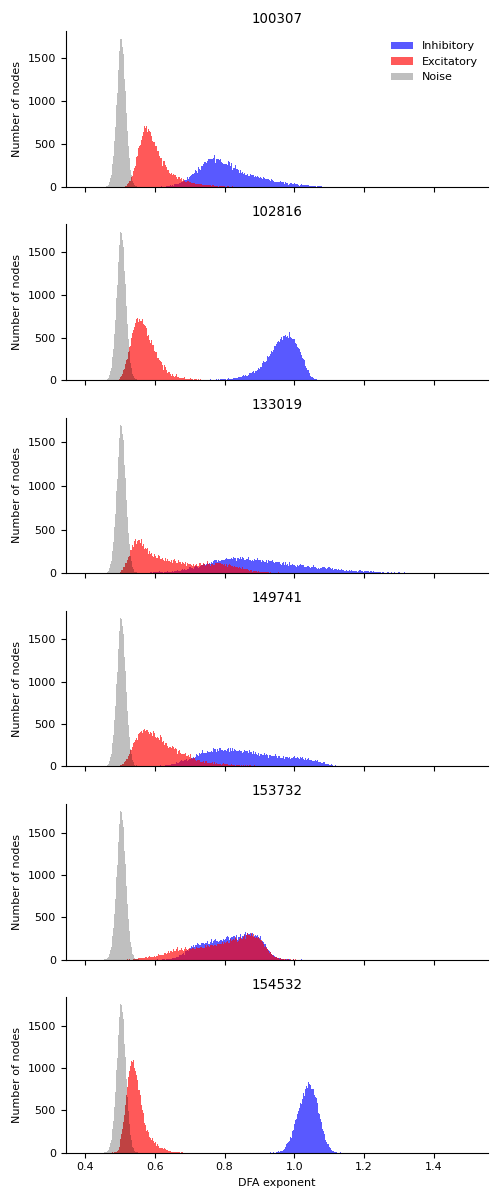

In [8]:
subject_ids = ['100307', '102816', '133019', '149741', '153732', '154532']
band = "broadband"
histogram_range = (0.4, 1.5)
number_of_bins = 400

figure_histograms, axes_histograms = plt.subplots(
    len(subject_ids), 1, figsize=(5,2 * len(subject_ids)), sharex=True
)

for row_index, subject_id in enumerate(subject_ids):
    axis = axes_histograms[row_index]

    excitatory_dfa = np.load(
        f'DFAexp_E_{band}_hcpmeg_10min_20khzsim_fftfilterdown500hz_125sec_polyorder3_adaptaps_{subject_id}.npy'
    )
    inhibitory_dfa = np.load(
        f'DFAexp_I_{band}_hcpmeg_10min_20khzsim_fftfilterdown500hz_125sec_polyorder3_adaptaps_{subject_id}.npy'
    )
    noise_dfa = np.concatenate((
        np.load(f'DFAexp_noise1_{band}_125sec_polyorder3_adaptaps.npy'),
        np.load(f'DFAexp_noise2_{band}_125sec_polyorder3_adaptaps.npy'),
        np.load(f'DFAexp_noise3_{band}_125sec_polyorder3_adaptaps.npy'),
    ))[:len(excitatory_dfa)]

    axis.hist(inhibitory_dfa, bins=number_of_bins, range=histogram_range, alpha=0.65, color='b', label='Inhibitory')
    axis.hist(excitatory_dfa, bins=number_of_bins, range=histogram_range, alpha=0.65, color='r', label='Excitatory')
    axis.hist(noise_dfa, bins=number_of_bins, range=histogram_range, alpha=0.25, color='k', label='Noise')

    axis.set_ylabel('Number of nodes')
    axis.set_title(subject_id)
    if row_index == 0:
        axis.legend(frameon=False)

axes_histograms[-1].set_xlabel('DFA exponent')
figure_histograms.tight_layout()
figure_histograms.savefig(
    f"DFAexp_{band}_hcpmeg_10min_20khzsim_fftfilterdown500hz_125sec_polyorder3_adaptaps_all_subjects_histograms.pdf",
    dpi=600, transparent=True
)

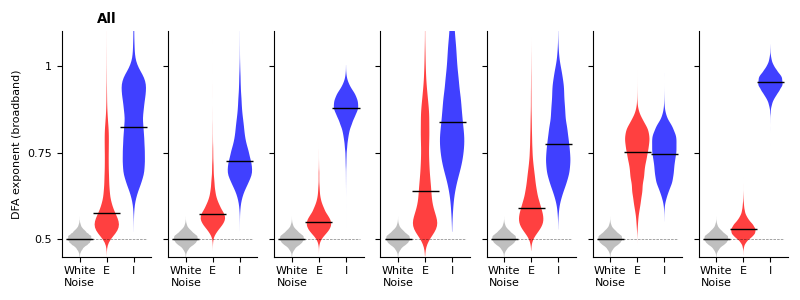

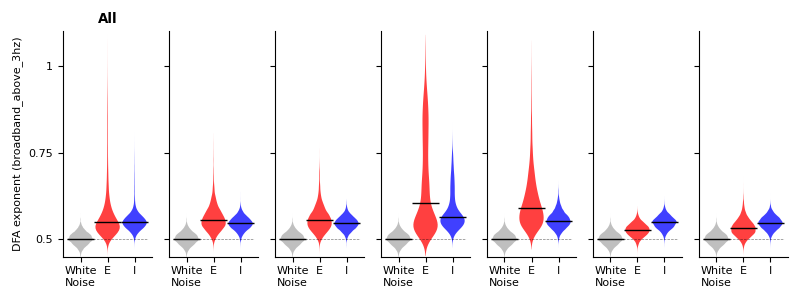

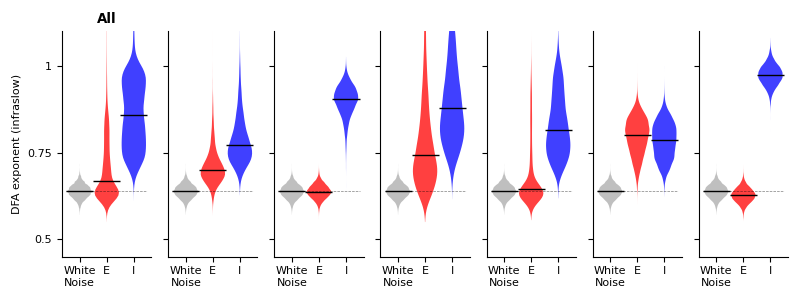

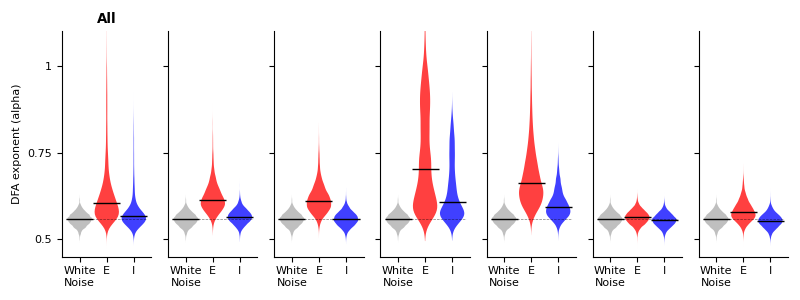

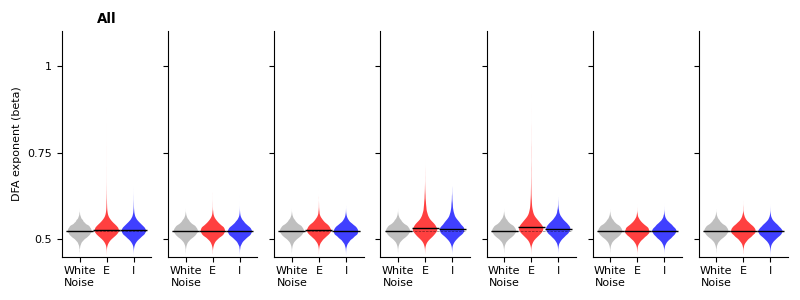

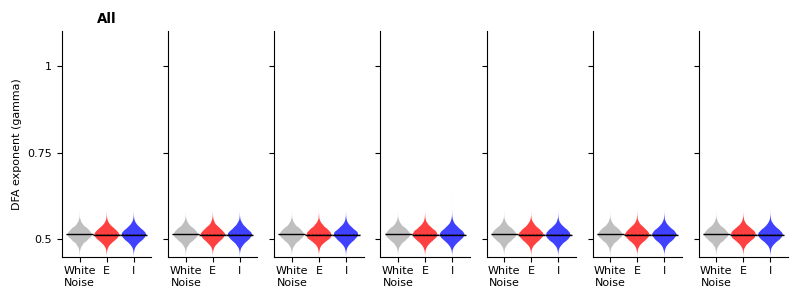

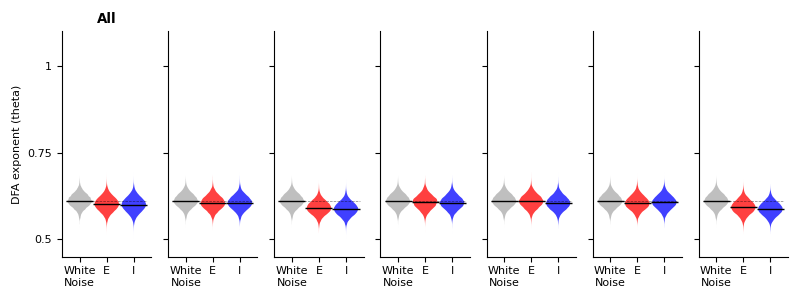

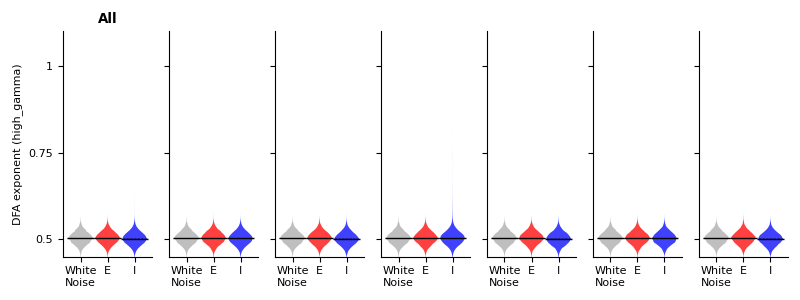

In [74]:
subject_ids = ['100307', '102816', '133019', '149741', '153732', '154532']

for band in ['broadband', 'broadband_above_3hz', 'infraslow', 'alpha', 'beta', 'gamma', 'theta', 'high_gamma']:

    # Collect all distributions keyed by subject
    all_excitatory_dfa = {}
    all_inhibitory_dfa = {}
    all_noise_dfa = {}

    for subject_id in subject_ids:
        all_excitatory_dfa[subject_id] = np.load(
            f'DFAexp_E_{band}_hcpmeg_10min_20khzsim_fftfilterdown500hz_230sec_polyorder3_adaptaps_{subject_id}.npy'
        )
        all_inhibitory_dfa[subject_id] = np.load(
            f'DFAexp_I_{band}_hcpmeg_10min_20khzsim_fftfilterdown500hz_230sec_polyorder3_adaptaps_{subject_id}.npy'
        )

    # One extra column for the aggregate panel on the left
    number_of_columns = 1 + len(subject_ids)
    figure_violins, axes_violins = plt.subplots(1, number_of_columns, figsize=(8, 3), sharey=True)

    # --- Per-subject panels (shifted one column to the right) ---
    for column_index, subject_id in enumerate(subject_ids):

        try:
            noise_dfa = np.concatenate((
                np.load(f'DFAexp_noise_{band}_230sec_polyorder3_adaptaps.npy'),
                np.load(f'DFAexp_noise_{band}_230sec_polyorder3_adaptaps.npy'),
                np.load(f'DFAexp_noise_{band}_230sec_polyorder3_adaptaps.npy'),
            ))[:len(all_excitatory_dfa[subject_id])]
        except:
            noise_dfa = np.concatenate((
                np.load(f'DFAexp_noise_{band}_hcpmeg_10min_20khzsim_fftfilterdown500hz_230sec_polyorder3_adaptaps_noise.npy'),
                np.load(f'DFAexp_noise_{band}_hcpmeg_10min_20khzsim_fftfilterdown500hz_230sec_polyorder3_adaptaps_noise.npy'),
                np.load(f'DFAexp_noise_{band}_hcpmeg_10min_20khzsim_fftfilterdown500hz_230sec_polyorder3_adaptaps_noise.npy'),
            ))[:len(all_excitatory_dfa[subject_id])]

        all_noise_dfa[subject_id] = noise_dfa
        noise_median = np.median(noise_dfa)

        axis = axes_violins[column_index + 1]  # +1 to leave room for aggregate
        violin_data = [
            noise_dfa,
            all_excitatory_dfa[subject_id],
            all_inhibitory_dfa[subject_id],
        ]
        violin_colors = ['k', 'r', 'b']
        violin_labels = ['White\nNoise', 'E', 'I']
        violin_alphas = [0.25, 0.75, 0.75]

        violin_parts = axis.violinplot(violin_data, positions=[0, 1, 2], showmedians=True, widths=0.9)

        axis.plot(np.linspace(-0.5, 2.5, 100), noise_median * np.ones(100), ls='--', c='k', alpha=0.5, lw=0.5)

        for body, color, alpha in zip(violin_parts['bodies'], violin_colors, violin_alphas):
            body.set_facecolor(color)
            body.set_alpha(alpha)

        violin_parts['cmedians'].set_color('k')
        violin_parts['cmedians'].set_linewidth(1)

        median_segments = violin_parts['cmedians'].get_segments()
        widened_segments = []
        for segment in median_segments:
            center_x = 0.5 * (segment[0, 0] + segment[1, 0])
            half_width = 0.5
            segment[0, 0] = center_x - half_width
            segment[1, 0] = center_x + half_width
            widened_segments.append(segment)
        violin_parts['cmedians'].set_segments(widened_segments)

        for part_name in ('cbars', 'cmins', 'cmaxes'):
            violin_parts[part_name].set_linewidth(0.0)

        axis.set_xticks([0, 1, 2])
        axis.set_xticklabels(violin_labels)
        axis.set_ylim(0.45, 1.1)

    # --- Aggregate panel (leftmost column) ---
    aggregate_excitatory_dfa = np.concatenate([all_excitatory_dfa[sid] for sid in subject_ids])
    aggregate_inhibitory_dfa = np.concatenate([all_inhibitory_dfa[sid] for sid in subject_ids])
    aggregate_noise_dfa = np.concatenate([all_noise_dfa[sid] for sid in subject_ids])
    aggregate_noise_median = np.median(aggregate_noise_dfa)

    aggregate_axis = axes_violins[0]
    aggregate_violin_data = [
        aggregate_noise_dfa,
        aggregate_excitatory_dfa,
        aggregate_inhibitory_dfa,
    ]

    aggregate_violin_parts = aggregate_axis.violinplot(
        aggregate_violin_data, positions=[0, 1, 2], showmedians=True, widths=0.9
    )

    aggregate_axis.plot(
        np.linspace(-0.5, 2.5, 100), aggregate_noise_median * np.ones(100),
        ls='--', c='k', alpha=0.5, lw=0.5
    )

    for body, color, alpha in zip(aggregate_violin_parts['bodies'], violin_colors, violin_alphas):
        body.set_facecolor(color)
        body.set_alpha(alpha)

    aggregate_violin_parts['cmedians'].set_color('k')
    aggregate_violin_parts['cmedians'].set_linewidth(1)

    aggregate_median_segments = aggregate_violin_parts['cmedians'].get_segments()
    aggregate_widened_segments = []
    for segment in aggregate_median_segments:
        center_x = 0.5 * (segment[0, 0] + segment[1, 0])
        half_width = 0.5
        segment[0, 0] = center_x - half_width
        segment[1, 0] = center_x + half_width
        aggregate_widened_segments.append(segment)
    aggregate_violin_parts['cmedians'].set_segments(aggregate_widened_segments)

    for part_name in ('cbars', 'cmins', 'cmaxes'):
        aggregate_violin_parts[part_name].set_linewidth(0.0)

    aggregate_axis.set_xticks([0, 1, 2])
    aggregate_axis.set_xticklabels(['White\nNoise', 'E', 'I'])
    aggregate_axis.set_ylim(0.45, 1.1)
    aggregate_axis.set_title('All', fontweight='bold')

    axes_violins[0].set_ylabel(f'DFA exponent ({band})')
    axes_violins[0].set_yticks([0.5, 0.75, 1], [0.5, 0.75, 1])
    figure_violins.tight_layout()
    figure_violins.savefig(
        f"DFAexp_{band}_hcpmeg_10min_20khzsim_fftfilterdown500hz_230sec_polyorder3_adaptaps_all_subjects_violins.pdf",
        dpi=600, transparent=True
    )

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
0.000363
0.00108
0.029901
0.001121
0.729358
0.796439
0.000468
0.032743
0.033655
0.227767
0.9924
1.0


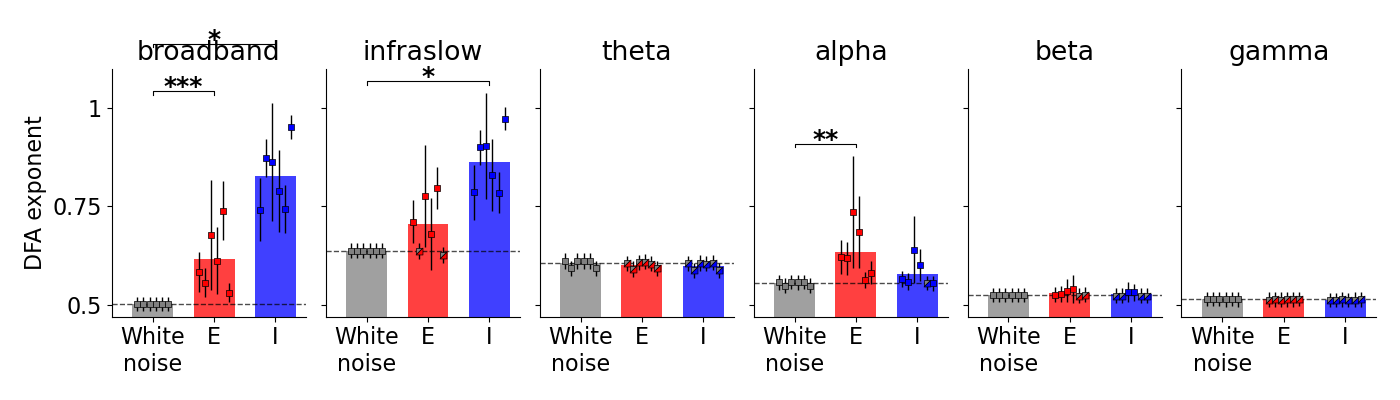

In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'pdf.fonttype':42})
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

from scipy.stats import mannwhitneyu

subject_ids = ['100307', '102816', '133019', '149741', '153732', '154532']
frequency_bands = ['broadband', 'infraslow', 'theta', 'alpha', 'beta', 'gamma']#, 'high_gamma']

number_of_bands = len(frequency_bands)
figure_bars, axes_bars = plt.subplots(1, number_of_bands, figsize=(14, 4), sharey=True)


from matplotlib.path import Path
import matplotlib.markers as mmarkers

# ── Custom diagonal-split square markers ──────────────────────────────
# A unit square split along the diagonal from bottom-left to top-right.
# Upper-left triangle: population color; Lower-right triangle: grey.
UPPER_LEFT_TRIANGLE_PATH = Path(
    [(-1, -1), (-1, 1), (1, 1), (-1, -1)],
    [Path.MOVETO, Path.LINETO, Path.LINETO, Path.CLOSEPOLY],
)
LOWER_RIGHT_TRIANGLE_PATH = Path(
    [(-1, -1), (1, 1), (1, -1), (-1, -1)],
    [Path.MOVETO, Path.LINETO, Path.LINETO, Path.CLOSEPOLY],
)


def plot_subject_markers_with_errorbars(axis, x_positions, means, stds,
                                        is_significant_per_subject, population_color,
                                        marker_size=5):
    """
    Plot subject-level markers with error bars.
    Significant subjects: solid colored square.
    Non-significant subjects: diagonally split square (population color / grey).
    """
    for subject_index in range(len(means)):
        x_position = x_positions[subject_index]
        subject_mean = means[subject_index]
        subject_std = stds[subject_index]

        # Error bar (no marker)
        axis.errorbar(
            x_position, subject_mean, yerr=subject_std,
            ecolor='k', elinewidth=1, ls='', zorder=3,
        )

        if is_significant_per_subject[subject_index]:
            # Fully colored square
            axis.scatter(
                x_position, subject_mean,
                marker='s', s=marker_size**2,
                c=population_color, edgecolors='k', linewidths=0.5, zorder=4,
            )
        else:
            # Upper-left triangle in population color
            axis.scatter(
                x_position, subject_mean,
                marker=UPPER_LEFT_TRIANGLE_PATH, s=marker_size**2,
                c='grey', edgecolors='k', linewidths=0.5, zorder=4,
            )
            # Lower-right triangle in grey
            axis.scatter(
                x_position, subject_mean,
                marker=LOWER_RIGHT_TRIANGLE_PATH, s=marker_size**2,
                c=population_color, edgecolors='k', linewidths=0.5, zorder=4,
            )



def one_sided_permutation_test(group_a, group_b, number_of_permutations=1000000):
    """One-sided permutation test: is mean(group_a) > mean(group_b)?"""
    observed_difference = np.mean(group_a) - np.mean(group_b)
    combined = np.concatenate([group_a, group_b])
    count_as_extreme = 0
    rng = np.random.default_rng(45)
    for _ in range(number_of_permutations):
        shuffled = rng.permutation(combined)
        permuted_difference = np.mean(shuffled[:len(group_a)]) - np.mean(shuffled[len(group_a):])
        if permuted_difference >= observed_difference:
            count_as_extreme += 1
    return count_as_extreme / number_of_permutations


def significance_label(p_value):
    if p_value < 0.005/12:
        return '***'
    elif p_value < 0.01/12:
        return '**'
    elif p_value < 0.05/12:
        return '*'
    else:
        return None


def draw_significance_bracket(axis, x_left, x_right, bracket_y, label, bracket_height=0.008):
    """Draw a horizontal bracket with a significance label centered above it."""
    axis.plot(
        [x_left, x_left, x_right, x_right],
        [bracket_y - bracket_height, bracket_y, bracket_y, bracket_y - bracket_height],
        lw=0.8, c='k', clip_on=False,
    )
    axis.text(
        0.5 * (x_left + x_right), bracket_y - 0.02, label,
        ha='center', va='bottom', fontsize=18, fontweight='bold', clip_on=False,
    )


PER_SUBJECT_SIGNIFICANCE_THRESHOLD = 0.01

for band_index, band in enumerate(frequency_bands):
    axis = axes_bars[band_index]

    # --- Load data per subject ---
    subject_excitatory_means = []
    subject_inhibitory_means = []
    subject_excitatory_stds = []
    subject_inhibitory_stds = []
    subject_noise_means = []
    subject_noise_stds = []
    subject_excitatory_significant = []
    subject_inhibitory_significant = []

    for subject_id in subject_ids:
        excitatory_dfa = np.load(
            f'DFAexp_E_{band}_hcpmeg_10min_20khzsim_fftfilterdown500hz_230sec_polyorder3_adaptaps_{subject_id}.npy'
        )
        inhibitory_dfa = np.load(
            f'DFAexp_I_{band}_hcpmeg_10min_20khzsim_fftfilterdown500hz_230sec_polyorder3_adaptaps_{subject_id}.npy'
        )

        noise_dfa = np.load(
                f'DFAexp_noise_{band}_hcpmeg_10min_20khzsim_fftfilterdown500hz_230sec_polyorder3_adaptaps_noise-{subject_id}.npy'
            )

        subject_excitatory_means.append(np.mean(excitatory_dfa))
        subject_excitatory_stds.append(np.std(excitatory_dfa))
        subject_inhibitory_means.append(np.mean(inhibitory_dfa))
        subject_inhibitory_stds.append(np.std(inhibitory_dfa))
        subject_noise_means.append(np.mean(noise_dfa))
        subject_noise_stds.append(np.std(noise_dfa))

        # Per-subject one-sided Mann-Whitney U: is E/I DFA > noise DFA?
        _, p_excitatory_subject = mannwhitneyu(excitatory_dfa, noise_dfa, alternative='greater')
        _, p_inhibitory_subject = mannwhitneyu(inhibitory_dfa, noise_dfa, alternative='greater')

        subject_excitatory_significant.append(p_excitatory_subject < PER_SUBJECT_SIGNIFICANCE_THRESHOLD)
        subject_inhibitory_significant.append(p_inhibitory_subject < PER_SUBJECT_SIGNIFICANCE_THRESHOLD)

    # --- Compute grand means ---
    excitatory_grand_mean = np.mean(subject_excitatory_means)
    inhibitory_grand_mean = np.mean(subject_inhibitory_means)
    noise_grand_mean = np.mean(subject_noise_means)

    # --- One-sided group permutation tests: E/I > noise ---
    p_value_excitatory_vs_noise = one_sided_permutation_test(
        np.array(subject_excitatory_means), np.array(subject_noise_means)
    )
    print(p_value_excitatory_vs_noise)
    p_value_inhibitory_vs_noise = one_sided_permutation_test(
        np.array(subject_inhibitory_means), np.array(subject_noise_means)
    )
    print(p_value_inhibitory_vs_noise)

    # --- Noise reference line ---
    axis.axhline(noise_grand_mean, ls='--', c='k', alpha=0.7, lw=1)

    # --- Draw bars ---
    bar_positions = [0, 0.6, 1.2]
    bar_heights = [noise_grand_mean, excitatory_grand_mean, inhibitory_grand_mean]
    bar_colors = ['grey', 'r', 'b']

    for position, height, color in zip(bar_positions, bar_heights, bar_colors):
        axis.bar(position, height, width=0.4, color=color, alpha=0.75, edgecolor='none')

    # --- Scatter individual subject means with errorbars ---
    scatter_half_width = 0.15
    subject_scatter_positions = np.linspace(-scatter_half_width, scatter_half_width, len(subject_ids))

    # Noise subjects (always grey)
    axis.errorbar(
        bar_positions[0] + subject_scatter_positions, subject_noise_means, yerr=subject_noise_stds,
        ecolor='k', elinewidth=1,
        marker='s', markersize=5, mfc='grey', mec='k', mew=0.5, zorder=3, ls='',
    )

    # Excitatory subjects
    excitatory_x_positions = bar_positions[1] + subject_scatter_positions
    plot_subject_markers_with_errorbars(
        axis, excitatory_x_positions,
        subject_excitatory_means, subject_excitatory_stds,
        subject_excitatory_significant, population_color='r',
    )

    # Inhibitory subjects
    inhibitory_x_positions = bar_positions[2] + subject_scatter_positions
    plot_subject_markers_with_errorbars(
        axis, inhibitory_x_positions,
        subject_inhibitory_means, subject_inhibitory_stds,
        subject_inhibitory_significant, population_color='b',
    )

    # --- Significance brackets (only if significant) ---
    label_excitatory = significance_label(p_value_excitatory_vs_noise)
    label_inhibitory = significance_label(p_value_inhibitory_vs_noise)

    if label_excitatory is not None or label_inhibitory is not None:
        highest_noise = np.max(np.array(subject_noise_means) + np.array(subject_noise_stds))
        highest_excitatory = np.max(np.array(subject_excitatory_means) + np.array(subject_excitatory_stds))
        highest_inhibitory = np.max(np.array(subject_inhibitory_means) + np.array(subject_inhibitory_stds))
        highest_point = max(highest_noise, highest_excitatory, highest_inhibitory)

        bracket_offset = 0.03
        bracket_spacing = 0.12

        if label_excitatory is not None and label_inhibitory is not None:
            draw_significance_bracket(
                axis, bar_positions[0], bar_positions[1],
                highest_point + bracket_offset, label_excitatory,
            )
            draw_significance_bracket(
                axis, bar_positions[0], bar_positions[2],
                highest_point + bracket_offset + bracket_spacing, label_inhibitory,
            )
        elif label_excitatory is not None:
            draw_significance_bracket(
                axis, bar_positions[0], bar_positions[1],
                highest_point + bracket_offset, label_excitatory,
            )
        elif label_inhibitory is not None:
            draw_significance_bracket(
                axis, bar_positions[0], bar_positions[2],
                highest_point + bracket_offset, label_inhibitory,
            )

    # --- Formatting ---
    axis.set_xticks(bar_positions)
    axis.set_xticklabels(['White\nnoise', 'E', 'I'])
    axis.set_title(band.replace('_', '\n'))
    axis.set_xlim(-0.4, 1.5)

for axis in axes_bars:
    axis.set_ylim(0.47, 1.1)

axes_bars[0].set_ylabel('DFA exponent')
axes_bars[0].set_yticks([0.5,0.75,1],[0.5,0.75,1])
figure_bars.tight_layout()
figure_bars.subplots_adjust(wspace=0.1)
# figure_bars.savefig(
#     "DFAexp_all_bands_bar_summary_winfraslow_multcomp.pdf",
#     dpi=600, transparent=True,
# )